In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/startup_funding.csv")

In [49]:
df.head()

,sr_no,date,startup_name,industry_vertical,sub_vertical,city,investor_name,investment_type,amount_usd,year,month
0,1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,2020.0,1.0
1,2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0,2020.0,1.0
2,3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,2020.0,1.0
3,4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0,2020.0,1.0
4,5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0,2020.0,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sr No              3044 non-null   int64
 1   Date dd/mm/yyyy    3044 non-null   str  
 2   Startup Name       3044 non-null   str  
 3   Industry Vertical  2873 non-null   str  
 4   SubVertical        2108 non-null   str  
 5   City  Location     2864 non-null   str  
 6   Investors Name     3020 non-null   str  
 7   InvestmentnType    3040 non-null   str  
 8   Amount in USD      2084 non-null   str  
 9   Remarks            419 non-null    str  
dtypes: int64(1), str(9)
memory usage: 237.9 KB


In [5]:
df.describe()

,Sr No
count,3044.000000
mean,1522.500000
std,878.871435
min,1.000000
25%,761.750000
50%,1522.500000
75%,2283.250000
max,3044.000000


In [6]:
df.shape

(3044, 10)

In [7]:
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='str')

In [8]:
df.isnull().sum()

Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64

In [9]:
(df.isnull().sum()/len(df) *100).round(2)

Sr No                 0.00
Date dd/mm/yyyy       0.00
Startup Name          0.00
Industry Vertical     5.62
SubVertical          30.75
City  Location        5.91
Investors Name        0.79
InvestmentnType       0.13
Amount in USD        31.54
Remarks              86.24
dtype: float64

In [10]:
df.drop(columns=['Remarks'], inplace=True)

In [11]:
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD'],
      dtype='str')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

Sr No                3044
Date dd/mm/yyyy      1035
Startup Name         2459
Industry Vertical     821
SubVertical          1942
City  Location        112
Investors Name       2412
InvestmentnType        55
Amount in USD         471
dtype: int64

In [21]:
df.rename(columns={
    'Sr No': 'sr_no',
    'Date dd/mm/yyyy': 'date',
    'Startup Name' : 'startup_name',
    'Industry Vertical' : 'industry_vertical',
    'SubVertical' : 'sub_vertical',
    'City  Location' : 'city',
    'Investors Name' : 'investor_name',
    'InvestmentnType' : 'investment_type',
    'Amount in USD' : 'amount_usd'
    
}, inplace=True)

In [14]:
df['Amount in USD'].head(30)

0     20,00,00,000
1        80,48,394
2      1,83,58,860
3        30,00,000
4        18,00,000
5        90,00,000
6     15,00,00,000
7        60,00,000
8      7,00,00,000
9      5,00,00,000
10     2,00,00,000
11     1,20,00,000
12     3,00,00,000
13       59,00,000
14       20,00,000
15     5,00,00,000
16    23,10,00,000
17    15,00,00,000
18        4,86,000
19       15,00,000
20     undisclosed
21     1,20,00,000
22     2,60,00,000
23     1,74,11,265
24       13,00,000
25    13,50,00,000
26        3,00,000
27    22,00,00,000
28     1,58,00,000
29    28,30,00,000
Name: Amount in USD, dtype: str

In [15]:
df['Amount in USD'] = df['Amount in USD'].str.replace(',', '')

In [16]:
df['Amount in USD'] = pd.to_numeric(
    df['Amount in USD'],
    errors='coerce'
)

In [17]:
df['Amount in USD'].dropna().loc[
    df['Amount in USD'].dropna() % 1 != 0
]

76    4889975.54
81    2739034.68
Name: Amount in USD, dtype: float64

In [18]:
df['Amount in USD'].dtype

dtype('float64')

In [23]:
df['date']=pd.to_datetime(
    df['date'],
    errors='coerce',
    dayfirst=True
)

In [24]:
df['date'].head(20)

0    2020-01-09
1    2020-01-13
2    2020-01-09
3    2020-01-02
4    2020-01-02
5    2020-01-13
6    2020-01-10
7    2019-12-12
8    2019-12-06
9    2019-12-03
10   2019-12-13
11   2019-12-17
12   2019-12-16
13   2019-12-16
14   2019-12-14
15   2019-12-11
16   2019-12-20
17   2019-11-13
18   2019-11-14
19   2019-11-13
Name: date, dtype: datetime64[us]

In [25]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month

In [33]:
df.isnull().sum()

sr_no                  0
date                   8
startup_name           0
industry_vertical    171
sub_vertical         936
city                 180
investor_name         24
investment_type        4
amount_usd           979
year                   8
month                  8
dtype: int64

In [36]:
categorical_column=[
    'industry_vertical',
    'sub_vertical',
    'city',
    'investor_name',
    'investment_type'
]
for col in categorical_column:
    df[col]=df[col].fillna('Unknown')

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.shape

(3044, 11)

In [41]:
total_funding=df['amount_usd'].sum()
print('Total Funding:', total_funding)

Total Funding: 38057737864.22


In [43]:
average_funding=df['amount_usd'].mean()
print('Average Funding:', average_funding .round(2))

Average Funding: 18429897.27


In [44]:
median_funding=df['amount_usd'].median()
print('Median Funding:', median_funding)

Median Funding: 1700000.0


In [47]:
#Q1. How has startup funding changed over the years?

yearly_funding=df.groupby('year')['amount_usd'].sum()
yearly_funding

year
2015.0    8.597207e+09
2016.0    3.828089e+09
2017.0    1.042931e+10
2018.0    5.116118e+09
2019.0    9.686577e+09
2020.0    3.902073e+08
Name: amount_usd, dtype: float64

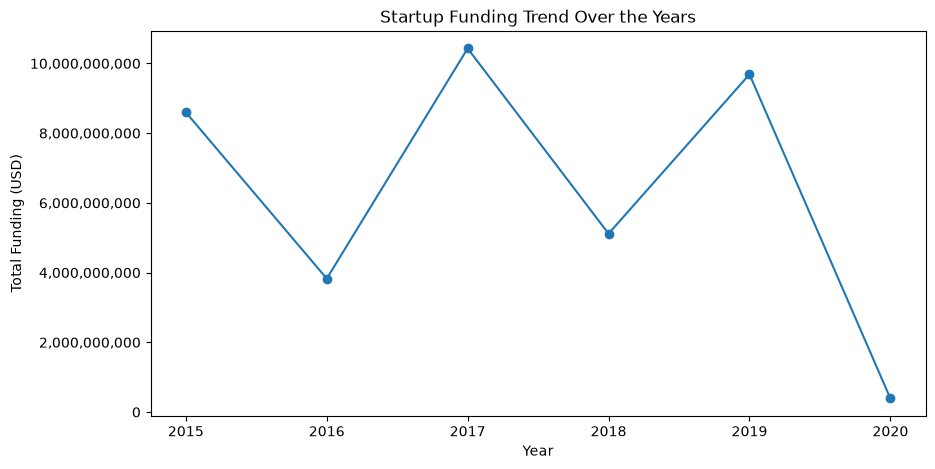

In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,5))

yearly_funding.plot(kind='line', marker='o')

plt.title('Startup Funding Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Funding (USD)')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.show()

In [53]:
#Q2. Which industries received the most funding?
industry_funding=(
    df.groupby('industry_vertical')['amount_usd'].sum()
    .sort_values(ascending=False)
    .head(10)
)
industry_funding

industry_vertical
Consumer Internet     6.253084e+09
eCommerce             5.002533e+09
Transportation        3.916632e+09
Technology            2.229708e+09
Finance               1.971438e+09
ECommerce             1.878798e+09
Unknown               1.231811e+09
FinTech               1.220711e+09
E-Commerce            1.008110e+09
Online Marketplace    7.001430e+08
Name: amount_usd, dtype: float64

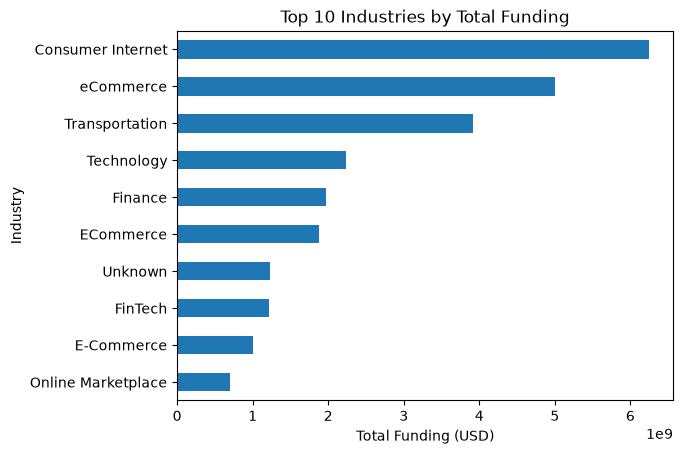

In [56]:
industry_funding.sort_values().plot(kind='barh')

plt.title('Top 10 Industries by Total Funding')
plt.xlabel('Total Funding (USD)')
plt.ylabel('Industry')

plt.show()

In [60]:
# Q3. Which cities have received the most startup funding?
city_funding=(
    df.groupby('city')['amount_usd'].sum()
    .sort_values(ascending=False)
    .head(10)
)
city_funding_billion = city_funding / 1e9

print(city_funding_billion.round(2))

city
Bengaluru     18.46
Mumbai         4.92
Gurugram       3.87
New Delhi      3.02
Unknown        1.27
Noida          1.26
Chennai        0.72
Pune           0.63
Menlo Park     0.45
Hyderabad      0.40
Name: amount_usd, dtype: float64


In [59]:
df['city'] = df['city'].replace({
    'Bangalore': 'Bengaluru',
    'Gurgaon': 'Gurugram'
})

In [61]:
df['city'].value_counts().head(20)

city
Bengaluru     841
Mumbai        567
New Delhi     421
Gurugram      337
Unknown       180
Pune          105
Hyderabad      99
Chennai        97
Noida          92
Ahmedabad      38
Delhi          34
Jaipur         30
Kolkata        21
Indore         13
Chandigarh     11
Goa            10
Vadodara       10
Singapore       8
Coimbatore      5
Kanpur          4
Name: count, dtype: int64

In [63]:
# Q4. What are the most common types of investments?
investment_types = df['investment_type'].value_counts()
investment_types

investment_type
Private Equity                 1356
Seed Funding                   1355
Seed/ Angel Funding              60
Seed / Angel Funding             47
Seed\\nFunding                   30
Debt Funding                     25
Series A                         24
Seed/Angel Funding               23
Series B                         20
Series C                         14
Series D                         12
Angel / Seed Funding              8
Seed Round                        7
Private Equity Round              4
Seed                              4
Unknown                           4
Pre-Series A                      4
Seed / Angle Funding              3
Series F                          2
Series E                          2
Corporate Round                   2
Venture Round                     2
pre-Series A                      2
Equity                            2
Pre-series A                      1
Series G                          1
Series H                          1
Venture     

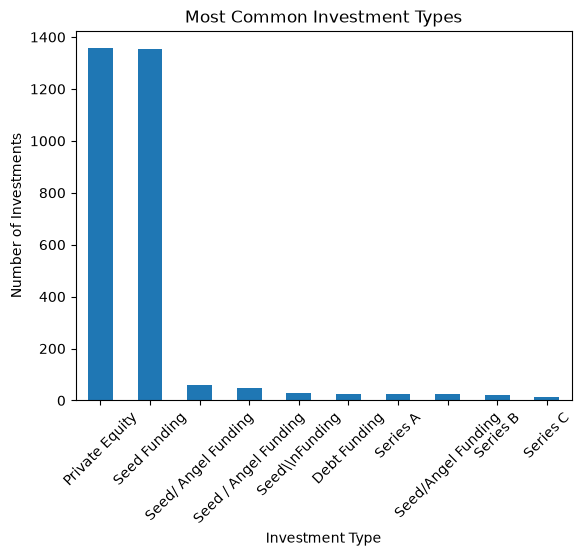

In [64]:
investment_types.head(10).plot(kind='bar')

plt.title('Most Common Investment Types')
plt.xlabel('Investment Type')
plt.ylabel('Number of Investments')
plt.xticks(rotation=45)
plt.show()

In [66]:
# Q5. Which startups received the highest funding?
top_startups=(
    df.groupby('startup_name')['amount_usd'].sum()
    .sort_values(ascending=False)
    .head(10)
)
top_startups_billion = top_startups / 1e9

print(top_startups_billion.round(2))

startup_name
Flipkart            4.06
Rapido Bike Taxi    3.90
Paytm               3.15
Ola                 0.98
Udaan               0.87
Snapdeal            0.70
Flipkart.com        0.70
Ola Cabs            0.67
True North          0.60
BigBasket           0.51
Name: amount_usd, dtype: float64


In [70]:
# Q6. Who are the most frequent investors?
top_investors= df['investor_name'].value_counts().head(10)
top_investors

investor_name
Undisclosed Investors       69
Ratan Tata                  25
Unknown                     24
Indian Angel Network        23
Kalaari Capital             16
Sequoia Capital             15
Group of Angel Investors    15
Accel Partners              12
Undisclosed Investor        12
Undisclosed                 11
Name: count, dtype: int64

In [69]:
df['investor_name'] = df['investor_name'].replace({
    'Undisclosed investors': 'Undisclosed Investors'
})

In [72]:
# Q7. How many startup funding deals occurred each year?
deals_by_year=df.groupby('year').size()
deals_by_year

year
2015.0    929
2016.0    993
2017.0    687
2018.0    309
2019.0    111
2020.0      7
dtype: int64

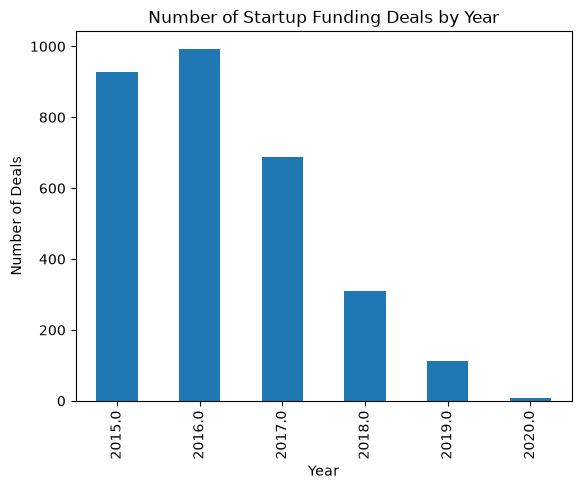

In [73]:
deals_by_year.plot(kind='bar')

plt.title('Number of Startup Funding Deals by Year')
plt.xlabel('Year')
plt.ylabel('Number of Deals')
plt.show()

In [75]:
df.to_csv("../data/clean_startup_funding.csv", index=False)

In [ ]:
# Key Insights

### 1. Startup Funding Trend
Startup funding varied considerably across the years in the dataset. Some years recorded substantially higher total funding than others, indicating changes in the level of investment activity over time.

### 2. Number of Funding Deals
The number of startup funding deals changed across the analyzed years. This shows that startup investment activity was not constant and varied from year to year.

### 3. Top Industries by Funding
The funding analysis shows that startup investment is concentrated in a limited number of industries. A few major industries account for a significant portion of the total recorded funding.

### 4. Top Cities by Funding
Startup funding is concentrated in major startup hubs. After standardizing city names such as Bangalore/Bengaluru and Gurgaon/Gurugram, the funding totals provide a more accurate comparison between cities.

### 5. Investment Types
The dataset contains several types of startup investments. The frequency analysis shows that some investment types occur much more often than others, indicating differences in how startups received funding.

### 6. Top Funded Startups
The funding distribution among startups is uneven. A relatively small number of startups account for large amounts of the recorded funding, while many startups received comparatively smaller amounts.

### 7. Top Investors
The investor analysis shows that some investors appear in the dataset more frequently than others. This indicates that certain investors participated in multiple startup funding deals during the period covered by the dataset.

### Overall Insight
The analysis indicates that Indian startup funding is influenced by factors such as year, industry, location, investment type, startup, and investor. Funding is not evenly distributed across these categories, with a smaller number of industries, cities, startups, and investors accounting for a substantial share of the recorded activity.